# Análise Exploratória de Dados

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp
from io import BytesIO
import requests

Esse é um exemplo de dataset real que não possui qualquer preparo para realização de análise de dados dificultando até mesmo qualquer tipo de análise exploratória.

In [2]:
fbi_citus_2010 = "./fbi_citus_2010.xls"

fbi_citus_2010_df= pd.read_excel(fbi_citus_2010, engine="xlrd")
fbi_citus_2010_df.head()

,Table 5,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,Crime in the United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"by State, 2010",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,State,Area,NaN,Population,Violent\ncrime,Murder and\nnonnegligent\nmanslaughter,Forcible\nrape,Robbery,Aggravated\nassault,Property\ncrime,Burglary,Larceny-\ntheft,Motor\nvehicle\ntheft,NaN
3,ALABAMA,Metropolitan Statistical Area,NaN,3424852,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
4,NaN,NaN,Area actually reporting,0.898,13207,215,949,4243,7800,124845,32759,83928,8158,NaN


In [3]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.shape

(891, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [6]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- O que cada linha representa?
- Qual é a variável-alvo?
- Quais variáveis são numéricas?
- Quais são categóricas?
- Quais são identificadores?
- Quais variáveis possuem valores ausentes?
- Quais variáveis podem ser redundantes?

In [8]:
df.isna().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [9]:
(df.isna().mean() * 100).sort_values(ascending=False)

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
sex             0.000000
pclass          0.000000
survived        0.000000
fare            0.000000
parch           0.000000
sibsp           0.000000
class           0.000000
adult_male      0.000000
who             0.000000
alive           0.000000
alone           0.000000
dtype: float64

> [ATENÇÃO] Tipo computacional não é tipo estatístico!

# Aplicando Medidas de Tendência Central

In [17]:
ages = df["age"].dropna()

print(ages.mean())

29.69911764705882


Fórmula da média aparada:
$$\bar{x}=\frac{\sum^{n-p}_{i=p+1}x_i}{n-2p}$$

In [18]:
tm = sp.stats.trim_mean(ages, proportiontocut=0.1)
print(tm)

29.26923076923077


Taxa de sobrevivência ponderada pela tarifa:
“Considerando o valor pago pelas passagens, qual foi a sobrevivência média ponderada dos passageiros?”

In [21]:
survived_fare = df[["survived", "fare"]].dropna()
survived_fare.head()

,survived,fare
0,0,7.2500
1,1,71.2833
2,1,7.9250
3,1,53.1000
4,0,8.0500


In [26]:
survived_avg = df['survived'].mean()

In [27]:
survived_w_fare_avg = np.average(survived_fare['survived'], weights=survived_fare['fare'])
print(survived_w_fare_avg)

0.5768194969243916


In [29]:
print(abs(survived_avg - survived_w_fare_avg))

0.1929811130860078


Fórmula da média ponderada:
$$\bar{x}_w=\frac{\sum^n_{i=1}w_ix_i}{\sum^n_1=1w_i}$$

# Aplicando Estimativas de Variabilidade

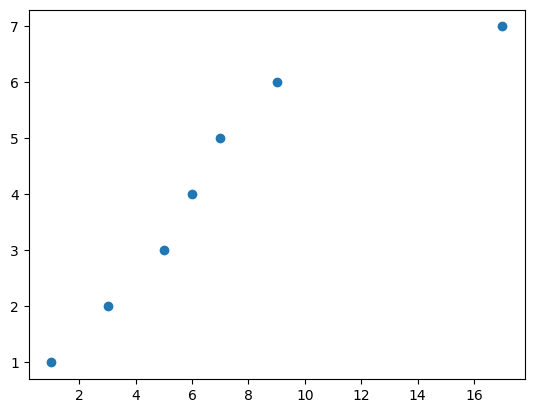

In [35]:
x = [1, 3, 5, 6, 7, 9, 17]
y = [1, 2, 3, 4, 5, 6, 7]
plt.scatter(x, y)